## Chargement du csv

Avant de lancer le notebook, il faut preparer l'espace de stockage HDFS et copié notre dataset. 

* `hdfs dfs -mkdir -p /projet/bronze /projet/silver /projet/gold`
  on crée 3 dossiers dans HDFS, un pour chaque étape de traitement de la donnée :
  **bronze** (données brutes telles quelles), **silver** (données nettoyées), **gold** (résultats finaux/prêts pour le ML et la dataviz)

* `hdfs dfs -put ai_student_impact_dataset.csv /projet/bronze/`
  on envoie le fichier CSV depuis notre machine locale vers HDFS, dans le dossier bronze. C'est obligatoire : Spark il peut lire les données que depuis HDFS

* `hdfs dfs -ls /projet/bronze`
  on vérifie que le fichier est bien arrivé dans HDFS


# Spark


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

java_home = os.environ.get("JAVA_HOME")
if not java_home:
    raise ValueError("JAVA_HOME manquant")
    
HDFS_URI = os.environ.get("HDFS_URI", "hdfs://localhost:9000")

print(f"JAVA_HOME utilisé : {java_home}")
print(f"HDFS_URI utilisé : {HDFS_URI}")

from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("ia-etudiants").getOrCreate()

print("spark up version :", spark.version)

JAVA_HOME utilisé : /opt/homebrew/opt/openjdk@11
HDFS_URI utilisé : hdfs://localhost:9000


Picked up JAVA_TOOL_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED
Picked up JAVA_TOOL_OPTIONS: --add-opens=java.base/java.lang=ALL-UNNAMED --add-opens=java.base/java.nio=ALL-UNNAMED --add-opens=java.base/sun.nio.ch=ALL-UNNAMED --add-opens=java.base/java.util=ALL-UNNAMED
26/07/20 16:40:19 WARN Utils: Your hostname, MacBook-Pro-de-messali.local resolves to a loopback address: 127.0.0.1; using 10.213.105.11 instead (on interface en0)
26/07/20 16:40:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/07/20 16:40:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLe

spark up version : 3.0.3


### Bronze - Chargement 

In [2]:
chemin_csv = f"{HDFS_URI}/projet/bronze/ai_student_impact_dataset.csv"
df_spark = spark.read.csv(chemin_csv, header=True, inferSchema=True)

print("fichier bien charger")
print("nombre de lignes :", df_spark.count())
print("nombre de colonnes :", len(df_spark.columns))

fichier bien charger
nombre de lignes : 50000
nombre de colonnes : 16


### Silver - cleaning dataset


In [3]:
nb_lignes = df_spark.count()
nb_ids_uniques = df_spark.select("Student_ID").distinct().count()
nb_doublons = nb_lignes - nb_ids_uniques

print(f"Lignes: {nb_lignes} et doublons (Student_ID): {nb_doublons}")

Lignes: 50000 et doublons (Student_ID): 0


In [4]:
from pyspark.sql.functions import col

for colonne in df_spark.columns:
    nb_manquants = df_spark.filter(col(colonne).isNull()).count()
    print(f"{colonne}: {nb_manquants}")

Student_ID: 0
Major_Category: 0
Year_of_Study: 0
Pre_Semester_GPA: 0
Weekly_GenAI_Hours: 0
Primary_Use_Case: 0
Prompt_Engineering_Skill: 0
Tool_Diversity: 0
Paid_Subscription: 0
Traditional_Study_Hours: 0
Perceived_AI_Dependency: 0
Institutional_Policy: 0
Anxiety_Level_During_Exams: 0
Post_Semester_GPA: 0
Skill_Retention_Score: 0
Burnout_Risk_Level: 0


In [5]:
df_spark.printSchema()

root
 |-- Student_ID: integer (nullable = true)
 |-- Major_Category: string (nullable = true)
 |-- Year_of_Study: string (nullable = true)
 |-- Pre_Semester_GPA: double (nullable = true)
 |-- Weekly_GenAI_Hours: double (nullable = true)
 |-- Primary_Use_Case: string (nullable = true)
 |-- Prompt_Engineering_Skill: string (nullable = true)
 |-- Tool_Diversity: integer (nullable = true)
 |-- Paid_Subscription: boolean (nullable = true)
 |-- Traditional_Study_Hours: double (nullable = true)
 |-- Perceived_AI_Dependency: integer (nullable = true)
 |-- Institutional_Policy: string (nullable = true)
 |-- Anxiety_Level_During_Exams: integer (nullable = true)
 |-- Post_Semester_GPA: double (nullable = true)
 |-- Skill_Retention_Score: double (nullable = true)
 |-- Burnout_Risk_Level: string (nullable = true)



In [6]:
from pyspark.sql.functions import mean
df_spark.select(mean("Post_Semester_GPA")).show()

+----------------------+
|avg(Post_Semester_GPA)|
+----------------------+
|            3.34929942|
+----------------------+



In [7]:
from pyspark.sql.functions import max
df_spark.select(max("Post_Semester_GPA")).show()

+----------------------+
|max(Post_Semester_GPA)|
+----------------------+
|                   4.0|
+----------------------+



In [8]:
from pyspark.sql.functions import min
df_spark.select(min("Post_Semester_GPA")).show()

+----------------------+
|min(Post_Semester_GPA)|
+----------------------+
|                   1.0|
+----------------------+



In [9]:
quartiles = df_spark.approxQuantile("Post_Semester_GPA", [0.25, 0.5, 0.75], 0.01)
print(quartiles)

[3.017, 3.416, 3.738]


In [10]:
# Liste des colonnes qui contiennent des nombres (pour calculer des statistiques dessus)
liste_colonnes = ["Pre_Semester_GPA", "Weekly_GenAI_Hours", "Tool_Diversity",
                              "Traditional_Study_Hours", "Perceived_AI_Dependency",
                              "Anxiety_Level_During_Exams", "Post_Semester_GPA", "Skill_Retention_Score"]

# Résumé statistique (moyenne, min, max, quartiles) sur ces colonnes, calculé par Spark
df_spark.select(liste_colonnes).summary().show()

+-------+------------------+------------------+------------------+-----------------------+-----------------------+--------------------------+------------------+---------------------+
|summary|  Pre_Semester_GPA|Weekly_GenAI_Hours|    Tool_Diversity|Traditional_Study_Hours|Perceived_AI_Dependency|Anxiety_Level_During_Exams| Post_Semester_GPA|Skill_Retention_Score|
+-------+------------------+------------------+------------------+-----------------------+-----------------------+--------------------------+------------------+---------------------+
|  count|             50000|             50000|             50000|                  50000|                  50000|                     50000|             50000|                50000|
|   mean|3.1461023400000303| 8.427752200000038|           2.80026|     11.209271000000108|                3.50536|                   4.27076|        3.34929942|    75.79812500000035|
| stddev|0.4788543560796032| 8.269489724680785|1.1880202692897102|      5.15642607133

In [11]:
from pyspark.sql.functions import sum as spark_sum, col

n = df_spark.count()

resultats = df_spark.select(
    spark_sum("Weekly_GenAI_Hours").alias("somme_x"),
    spark_sum("Post_Semester_GPA").alias("somme_y"),
    spark_sum(col("Weekly_GenAI_Hours") * col("Post_Semester_GPA")).alias("somme_xy"),
    spark_sum(col("Weekly_GenAI_Hours") * col("Weekly_GenAI_Hours")).alias("somme_x2")
).collect()[0]

print("n =", n)
print("somme_x =", resultats["somme_x"])
print("somme_y =", resultats["somme_y"])
print("somme_xy =", resultats["somme_xy"])
print("somme_x2 =", resultats["somme_x2"])

n = 50000
somme_x = 421387.61000000185
somme_y = 167464.971
somme_xy = 1407541.2743599913
somme_x2 = 6970504.9881000165


In [12]:
# Formules mathématiques de la régression linéaire simple (une seule variable)
a = (n * resultats["somme_xy"] - resultats["somme_x"] * resultats["somme_y"]) / (n * resultats["somme_x2"] - resultats["somme_x"] ** 2)
b = (resultats["somme_y"] - a * resultats["somme_x"]) / n

print("a (pente) =", a)
print("b (ordonnée à l'origine) =", b)

a (pente) = -0.0011148964641097014
b (ordonnée à l'origine) = 3.358695491128173


In [13]:
from pyspark.sql.functions import sum as spark_sum, col

n = df_spark.count()

stats = df_spark.select(
    spark_sum("Weekly_GenAI_Hours").alias("sum_x1"),
    spark_sum("Traditional_Study_Hours").alias("sum_x2"),
    spark_sum("Post_Semester_GPA").alias("sum_y"),
    spark_sum(col("Weekly_GenAI_Hours") * col("Weekly_GenAI_Hours")).alias("sum_x1x1"),
    spark_sum(col("Traditional_Study_Hours") * col("Traditional_Study_Hours")).alias("sum_x2x2"),
    spark_sum(col("Weekly_GenAI_Hours") * col("Traditional_Study_Hours")).alias("sum_x1x2"),
    spark_sum(col("Weekly_GenAI_Hours") * col("Post_Semester_GPA")).alias("sum_x1y"),
    spark_sum(col("Traditional_Study_Hours") * col("Post_Semester_GPA")).alias("sum_x2y"),
).collect()[0]

print(stats)

Row(sum_x1=421387.61000000185, sum_x2=560463.5500000054, sum_y=167464.971, sum_x1x1=6970504.9881000165, sum_x2x2=7611797.720300019, sum_x1x2=4387938.451599997, sum_x1y=1407541.2743599913, sum_x2y=1894751.2894200005)


In [14]:
import numpy as np

# Matrice A : les "coefficients" du système d'équations (3x3, car 2 variables + 1 constante)
A = np.array([
    [stats["sum_x1x1"], stats["sum_x1x2"], stats["sum_x1"]],
    [stats["sum_x1x2"], stats["sum_x2x2"], stats["sum_x2"]],
    [stats["sum_x1"],   stats["sum_x2"],   n]
])

# Vecteur B : ce qu'on veut atteindre
B = np.array([stats["sum_x1y"], stats["sum_x2y"], stats["sum_y"]])

# Résolution du système (numpy fait ça pour nous, c'est de l'algèbre pure, pas du ML)
a1, a2, b = np.linalg.solve(A, B)

print("a1 (poids Weekly_GenAI_Hours) =", a1)
print("a2 (poids Traditional_Study_Hours) =", a2)
print("b (constante) =", b)

a1 (poids Weekly_GenAI_Hours) = 0.0001881948890953249
a2 (poids Traditional_Study_Hours) = 0.013279717267157385
b (constante) = 3.1988574104584497


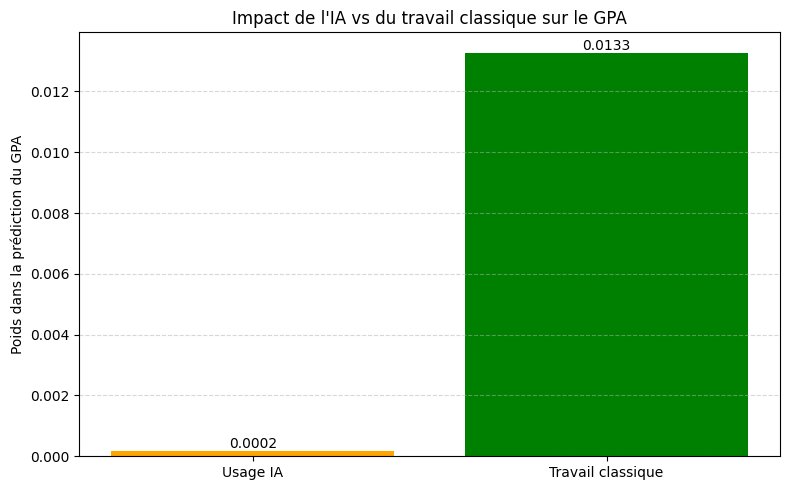

In [23]:
plt.figure(figsize=(8, 5))
poids = [a1, a2]
noms = ["Usage IA", "Travail classique"]

barres = plt.bar(noms, poids, color=["orange", "green"])
plt.ylabel("Poids dans la prédiction du GPA")
plt.title("Impact de l'IA vs du travail classique sur le GPA")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for barre in barres:
    valeur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width()/2, valeur, f"{valeur:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [15]:
from pyspark.sql.functions import when, avg

# Seuils : on définit "peu réviser" et "beaucoup utiliser l'IA" par rapport à la médiane
mediane_etude = df_spark.approxQuantile("Traditional_Study_Hours", [0.5], 0.01)[0]
mediane_ia = df_spark.approxQuantile("Weekly_GenAI_Hours", [0.5], 0.01)[0]

df_groupes = df_spark.withColumn(
    "groupe",
    when((col("Traditional_Study_Hours") < mediane_etude) & (col("Weekly_GenAI_Hours") >= mediane_ia), 
         "Peu de révisions + Beaucoup IA")
    .otherwise("Autres profils")
)

df_groupes.groupBy("groupe").agg(avg("Post_Semester_GPA").alias("gpa_moyen")).show()

+--------------------+------------------+
|              groupe|         gpa_moyen|
+--------------------+------------------+
|Peu de révisions ...|3.3034086623453227|
|      Autres profils| 3.366403882055782|
+--------------------+------------------+



In [16]:
df_groupes3 = df_spark.withColumn(
    "groupe",
    when((col("Traditional_Study_Hours") < mediane_etude) & (col("Weekly_GenAI_Hours") >= mediane_ia),
         "Peu de révisions + Beaucoup IA")
    .when((col("Traditional_Study_Hours") < mediane_etude) & (col("Weekly_GenAI_Hours") < mediane_ia),
         "Peu de révisions + Peu IA")
    .otherwise("Autres profils (révise normalement/beaucoup)")
)

df_groupes3.groupBy("groupe").agg(avg("Post_Semester_GPA").alias("gpa_moyen")).show(truncate=False)

+--------------------------------------------+------------------+
|groupe                                      |gpa_moyen         |
+--------------------------------------------+------------------+
|Peu de révisions + Beaucoup IA              |3.3034086623453227|
|Autres profils (révise normalement/beaucoup)|3.4037956929654394|
|Peu de révisions + Peu IA                   |3.2817891247872475|
+--------------------------------------------+------------------+



In [17]:
correlation = df_spark.corr("Weekly_GenAI_Hours", "Traditional_Study_Hours")
print("Corrélation IA / temps de travail classique :", correlation)

Corrélation IA / temps de travail classique : -0.15736782795222648


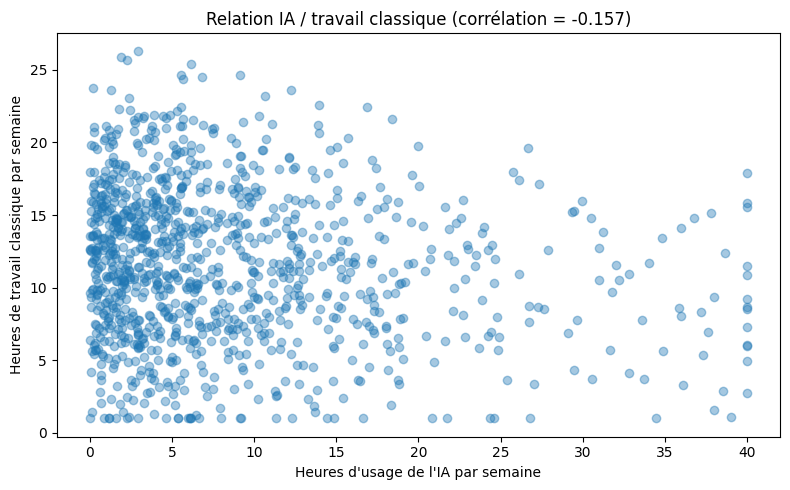

In [24]:
# On prend un échantillon aléatoire de 1000 étudiants (pas tout le dataset) pour le graphique
echantillon = df_spark.select("Weekly_GenAI_Hours", "Traditional_Study_Hours").sample(fraction=0.02, seed=42).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(echantillon["Weekly_GenAI_Hours"], echantillon["Traditional_Study_Hours"], alpha=0.4)
plt.xlabel("Heures d'usage de l'IA par semaine")
plt.ylabel("Heures de travail classique par semaine")
plt.title(f"Relation IA / travail classique (corrélation = {correlation:.3f})")
plt.tight_layout()
plt.show()

In [18]:
from pyspark.sql.functions import corr, avg

df_spark.groupBy("Major_Category").agg(
    avg("Weekly_GenAI_Hours").alias("moy_heures_ia"),
    avg("Traditional_Study_Hours").alias("moy_heures_etude"),
    corr("Weekly_GenAI_Hours", "Traditional_Study_Hours").alias("correlation"),
    avg("Post_Semester_GPA").alias("gpa_moyen")
).show(truncate=False)

+--------------+------------------+------------------+--------------------+------------------+
|Major_Category|moy_heures_ia     |moy_heures_etude  |correlation         |gpa_moyen         |
+--------------+------------------+------------------+--------------------+------------------+
|Humanities    |6.770144086451857 |11.336752051230754|-0.12973110279338304|3.3458254952971833|
|STEM          |10.488608805365551|11.004719436881617|-0.18102501294098639|3.363154127100074 |
|Arts          |7.271702342828255 |11.352411933254679|-0.13125472630306917|3.3436878476318896|
|Business      |8.275898069867607 |11.205091721167662|-0.15056943217177662|3.3360853405646935|
|Medical       |7.546727918468176 |11.365145151327981|-0.1529071484856231 |3.353167850525014 |
+--------------+------------------+------------------+--------------------+------------------+



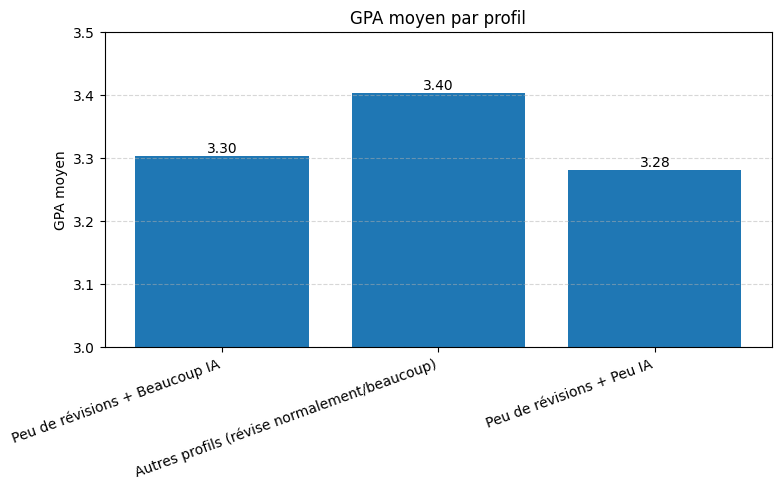

In [22]:
import matplotlib.pyplot as plt

resultat_groupes = df_groupes3.groupBy("groupe").agg(avg("Post_Semester_GPA").alias("gpa_moyen")).toPandas()

plt.figure(figsize=(8, 5))
barres = plt.bar(resultat_groupes["groupe"], resultat_groupes["gpa_moyen"])
plt.ylabel("GPA moyen")
plt.title("GPA moyen par profil")
plt.ylim(3.0, 3.5)
plt.xticks(rotation=20, ha="right")

# Grille horizontale, pour repérer facilement les niveaux
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Affiche le chiffre exact au-dessus de chaque barre
for barre in barres:
    valeur = barre.get_height()
    plt.text(barre.get_x() + barre.get_width()/2, valeur + 0.005, f"{valeur:.2f}", ha="center")

plt.tight_layout()
plt.show()

In [26]:
from pyspark.sql.functions import pow as spark_pow, col, avg

# Conversion des coefficients numpy en nombres Python classiques (nécessaire pour Spark)
a1_py = float(a1)
a2_py = float(a2)
b_py = float(b)

df_predictions = df_spark.withColumn(
    "gpa_predit",
    a1_py * col("Weekly_GenAI_Hours") + a2_py * col("Traditional_Study_Hours") + b_py
)

erreur_moyenne = df_predictions.select(
    spark_pow(col("Post_Semester_GPA") - col("gpa_predit"), 2).alias("erreur_carree")
).agg(avg("erreur_carree")).collect()[0][0]

rmse = erreur_moyenne ** 0.5

print("RMSE du modèle :", rmse)

RMSE du modèle : 0.49094666757877675
